# 5. Gradient corrections: PBE, revPBE and PBEsol

Every notebook up to here used the **local density approximation**: the exchange-correlation
energy density at a point depends on the density *at that point* and nothing else,

    E_xc = integral rho(r) e_xc(rho(r)) dr.

That is exact for a uniform electron gas and only that. A real density is not uniform, and
the cheapest way to tell the functional so is to hand it the density's **gradient** as
well:

    E_xc = integral e_xc(rho(r), |grad rho(r)|^2) dr.

Functionals of that form are **generalised gradient approximations**, and PBE (Perdew,
Burke and Ernzerhof, 1996) is the one nearly all published plane-wave work uses. This
notebook covers what it takes to support them:

1. how Quantum ESPRESSO *composes* a functional, and why a name like `PBE` is not one
   thing but four;
2. the enhancement factor, which is the whole of PBE exchange;
3. why writing only the energy is worth more here than it was for LDA;
4. the second term in the potential, which is a divergence and costs four FFTs;
5. the same thing on a PAW sphere, where "gradient" and "divergence" mean something else;
6. every energy against Quantum ESPRESSO, on all three kinds of pseudopotential;
7. the band structure, and what a gradient correction does and does not fix.

In [1]:
from pathlib import Path

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from pypresso.io import read_qe_output
from pypresso.io.pwin import read_pw_input
from pypresso.pseudo import read_upf
from pypresso.scf import run_scf
from pypresso.scf.driver import Calculation
from pypresso.system import build_system
from pypresso.workflows import run_bands
from pypresso.xc.functional import get_functional, resolve_functional

CASES = Path('../tests/data/qe')
PSEUDO = Path('../tests/data/pseudo')

def load(case):
    system = build_system(read_pw_input(CASES / f'{case}.in'))
    pseudos = tuple(read_upf(PSEUDO / s.pseudo_file) for s in system.structure.species)
    return system, pseudos

def reference(case):
    return read_qe_output(CASES / f'reference.out.{case}')

## 1. A functional is four choices, not one

QE does not have a table of functionals. It has four **slots** — local exchange, local
correlation, and a gradient correction to each — filled independently, and a name like
`PBE` is shorthand for one particular filling (`XClib/qe_dft_list.f90`). That matters here
for a practical reason: a UPF file records the four terms its dataset was generated with,
and a calculation has to use the same ones.

In [2]:
for name in ['PZ', 'PW', 'PBE', 'REVPBE', 'PBESOL']:
    f = get_functional(name)
    print(f'{name:8s} exchange={f.exchange.__name__:18s} correlation={f.correlation.__name__:16s} '
          f'gradient={f.is_gradient}')

PZ       exchange=slater_exchange    correlation=pz_correlation   gradient=False
PW       exchange=slater_exchange    correlation=pw_correlation   gradient=False
PBE      exchange=slater_exchange    correlation=pw_correlation   gradient=True
REVPBE   exchange=slater_exchange    correlation=pw_correlation   gradient=True
PBESOL   exchange=slater_exchange    correlation=pw_correlation   gradient=True


Read the correlation column. **PBE's local half uses Perdew-Wang correlation, not
Perdew-Zunger** — the parameterisation an LDA run uses is not the one PBE's gradient term
was fitted on top of. "PBE = LDA + a gradient correction" is wrong in a way that converges
perfectly well and matches nothing.

The functional a run uses comes from the pseudopotentials themselves:

In [3]:
for name in ['Si.pz-vbc.UPF', 'Si.pbe-rrkj.UPF', 'Si.pbe-n-kjpaw_psl.0.1.UPF']:
    pseudo = read_upf(PSEUDO / name)
    resolved = resolve_functional([pseudo.functional])
    print(f'{name:30s} header={pseudo.functional!r:26s} -> {resolved.name}')

Si.pz-vbc.UPF                  header='SLA  PZ   NOGX NOGC'      -> PZ
Si.pbe-rrkj.UPF                header='SLA  PW   PBE  PBE'       -> PBE
Si.pbe-n-kjpaw_psl.0.1.UPF     header='SLA  PW   PBX  PBC'       -> PBE


Look at the second header. Its gradient slots are spelled `PBE`, not `PBX`/`PBC` -- a
legacy alias (`igcx = 14`, `igcc = 9`) that QE still maps back under a "TO BE REMOVED"
comment older than several releases. The newer PSlibrary datasets use the canonical names,
the older ones do not, and a parser that knows only the canonical names sees *no gradient
terms at all* in the older ones and runs a PBE dataset as LDA. Nothing about that fails;
the energy is just wrong.

`input_dft` in the `&system` namelist overrides the headers, which is how QE's own
`pw_dft` tests compare functionals on one fixed dataset. It warns, because the combination
is inconsistent by construction.

## 2. The enhancement factor

PBE exchange is Slater exchange multiplied by a function of one dimensionless variable —
the reduced gradient `s = |grad rho| / (2 k_F rho)`, which asks how fast the density varies
on the scale of its own Fermi wavelength:

    F(s) = 1 + kappa - kappa / (1 + mu s^2 / kappa).

`F(0) = 1` recovers the uniform gas exactly, and `F` saturates at `1 + kappa` however
sharply the density varies — which is the Lieb-Oxford bound, and the reason the form was
chosen. The three members of the family differ only in the two constants.

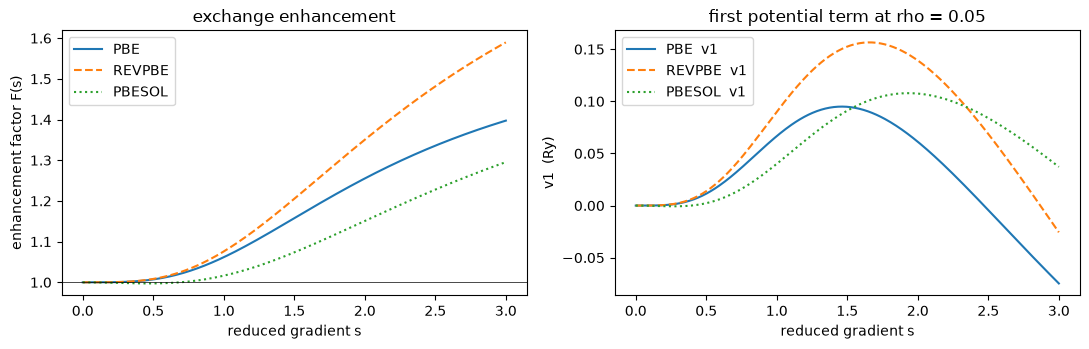

In [4]:
rho = 0.05
s = np.linspace(0.0, 3.0, 300)
kf = (3.0 * np.pi**2 * rho) ** (1.0 / 3.0)
sigma = (s * 2.0 * kf * rho) ** 2   # |grad rho|^2 for each s at fixed rho

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for name, style in [('PBE', '-'), ('REVPBE', '--'), ('PBESOL', ':')]:
    f = get_functional(name)
    ex_gga = np.asarray(f.gradient_energy(jnp.full_like(sigma, rho), jnp.asarray(sigma)))
    ex_lda = float(rho * f.exchange(jnp.asarray(rho)))
    ax[0].plot(s, 1.0 + ex_gga / ex_lda, style, label=name)

    v1, v2 = f.gradient_potentials(jnp.full_like(sigma, rho), jnp.asarray(sigma))
    ax[1].plot(s, np.asarray(v1), style, label=f'{name}  v1')

ax[0].set_xlabel('reduced gradient s'); ax[0].set_ylabel('enhancement factor F(s)')
ax[0].axhline(1.0, color='k', lw=0.5); ax[0].legend(); ax[0].set_title('exchange enhancement')
ax[1].set_xlabel('reduced gradient s'); ax[1].set_ylabel('v1  (Ry)')
ax[1].legend(); ax[1].set_title(f'first potential term at rho = {rho}')
fig.tight_layout()

revPBE raises `kappa` (0.804 to 1.245), which lets exchange keep growing with `s` and
improves atomisation energies; PBEsol lowers `mu` to the gradient expansion's 10/81, which
gives back the correct behaviour for slowly varying densities and better lattice constants.
The three curves are the entire difference between the functionals, plus one constant in
correlation.

## 3. Only the energy is written down

For LDA the potential was `v_xc = d(rho e_xc)/d rho`, obtained by `jax.grad` rather than by
a second hand-derivation. A GGA makes the same argument much more forcefully, because
there are now **two** derivatives to keep consistent with the energy:

    v1 = d e / d rho,        v2 = 2 d e / d sigma,     sigma = |grad rho|^2.

QE hand-derives four routines' worth of these (`v1x`, `v2x`, `v1c`, `v2c`), and `v1c`
contains `d(rho ec)/d rho` for the *local* correlation — so its correctness depends on the
gradient routine and the local routine agreeing about which parameterisation is in use.
Here both come out of the energy expression by differentiation. The check is against QE's
algebra, transcribed independently in `tests/unit/test_xc.py`:

In [5]:
def qe_pbex(rho, grho, kappa=0.804, mu=0.2195149727645171):
    # pbex transcribed from XClib: returns (sx, v1x, v2x), in Hartree.
    c1, c2 = 0.75 / np.pi, 3.093667726280136
    agrho = np.sqrt(grho); kf = c2 * rho ** (1/3); dsg = 0.5 / kf
    s1 = agrho * dsg / rho; f2 = 1.0 + s1 * s1 * mu / kappa
    fx = kappa - kappa / f2; exunif = -c1 * kf
    dfx = 2.0 * mu * s1 / (f2 * f2)
    v1x = exunif * fx + exunif / 3.0 * fx + exunif * dfx * (-4.0 / 3.0 * s1)
    return exunif * fx * rho, v1x, exunif * dfx * dsg / agrho

import jax

E2 = 2.0            # XClib returns Hartree, QE multiplies by e2; this code returns Ry
pbe = get_functional('PBE')
energy = pbe.gradient_exchange                      # PBE exchange alone, to match pbex

print(f"{'rho':>6} {'sigma':>6} | {'v1 autodiff':>13} {'v1 QE':>13} | {'v2 autodiff':>13} {'v2 QE':>13}")
for r, sig in [(0.05, 0.01), (0.5, 0.3), (2.0, 5.0)]:
    v1 = float(jax.grad(energy, argnums=0)(r, sig))
    v2 = 2.0 * float(jax.grad(energy, argnums=1)(r, sig))
    _, v1_qe, v2_qe = qe_pbex(r, sig)
    print(f'{r:6.2f} {sig:6.2f} | {v1:13.9f} {E2*v1_qe:13.9f} | {v2:13.9f} {E2*v2_qe:13.9f}')

   rho  sigma |   v1 autodiff         v1 QE |   v2 autodiff         v2 QE
  0.05   0.01 |   0.066124366   0.066124366 |  -0.627914775  -0.627914775
  0.50   0.30 |   0.016393593   0.016393593 |  -0.041548429  -0.041548429
  2.00   5.00 |   0.011017096   0.011017096 |  -0.006647590  -0.006647590


## 4. The second term is a divergence

The functional derivative of an energy that depends on `grad rho` has two pieces:

    v_xc(r) = v1(r) - div ( v2(r) grad rho(r) ).

The first is pointwise, like LDA's. The second is not: it needs `grad rho` on the whole
grid, and then the divergence of a vector field built from it. Both are exact in G space —
`grad f = sum_G i G f_G exp(iGr)` — so a gradient-corrected potential costs **four extra
FFTs per iteration**: three to build the gradient, one to take the divergence back.

Here is the potential of a converged silicon density, split into its parts along the line
joining the two atoms.

functional: PBE,  converged in 8 iterations


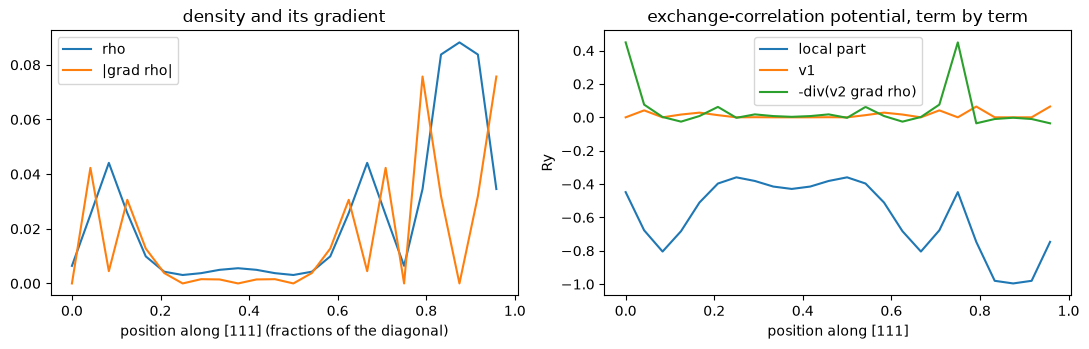

In [6]:
system, pseudos = load('si2-nc-pbe')
scf = run_scf(system, pseudos, conv_thr=1e-10, max_iterations=80)
calculation = Calculation(system, pseudos)
print(f'functional: {calculation.functional.name},  converged in {scf.iterations} iterations')

from pypresso.basis.fft import r_to_g
from pypresso.basis.gradients import divergence, gradient
from pypresso.scf.potential import exchange_correlation

dense, cell = calculation.basis.dense, system.cell
rho = scf.density
rho_g = r_to_g(rho, dense.fft_index)

grad = gradient(rho_g, dense, cell)
sigma = jnp.sum(grad * grad, axis=0)
v1, v2 = calculation.functional.gradient_potentials(rho, sigma)
v_divergence = -divergence(v2[None, ...] * grad, dense, cell)
v_local, _ = exchange_correlation(rho, cell, None, calculation.functional)

n = dense.grid[0]
line = (np.arange(n), np.arange(n), np.arange(n))   # the [111] body diagonal, through both atoms
x = np.arange(n) / n

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(x, np.asarray(rho)[line], label='rho')
ax[0].plot(x, np.asarray(jnp.sqrt(sigma))[line], label='|grad rho|')
ax[0].set_xlabel('position along [111] (fractions of the diagonal)')
ax[0].legend(); ax[0].set_title('density and its gradient')

ax[1].plot(x, np.asarray(v_local)[line], label='local part')
ax[1].plot(x, np.asarray(v1)[line], label='v1')
ax[1].plot(x, np.asarray(v_divergence)[line], label='-div(v2 grad rho)')
ax[1].set_xlabel('position along [111]'); ax[1].set_ylabel('Ry')
ax[1].legend(); ax[1].set_title('exchange-correlation potential, term by term')
fig.tight_layout()

The correction is not a small perturbation on the local potential, and the divergence term
is the larger half of it -- which is the whole content of a gradient correction: it acts
where the density is *changing*, and on a real crystal that is most of the region that
matters.

That the divergence term integrates to zero over the cell is not an accident but a
consequence of periodicity, and it is worth checking, because a sign error in it survives
self-consistency and surfaces only in the total energy:

In [7]:
print(f'integral of -div(v2 grad rho) over the cell: {float(jnp.sum(v_divergence)):.3e}')
print(f'largest |local part|:                        {float(jnp.max(jnp.abs(v_local))):.4f} Ry')
print(f'largest |v1|:                                {float(jnp.max(jnp.abs(v1))):.4f} Ry')
print(f'largest |div term|:                          {float(jnp.max(jnp.abs(v_divergence))):.4f} Ry')

integral of -div(v2 grad rho) over the cell: -3.109e-15
largest |local part|:                        0.9959 Ry
largest |v1|:                                0.0693 Ry
largest |div term|:                          0.4494 Ry


## 5. The same thing on a PAW sphere

PAW recomputes the exchange-correlation energy on each atom's own radial mesh, where the
density is carried as multipoles `rho_lm(r)` and put back on a spherical quadrature to be
fed to the functional. A gradient correction needs `grad rho` **there**, in spherical
coordinates, and then a spherical divergence — which is a different piece of code from the
G-space one, and three details of it are QE's rather than obvious:

- the angular part of the gradient costs nothing extra: `rho` is a sum of harmonics, so its
  angular derivatives are the *harmonics'* derivatives contracted with the same `rho_lm`;
- the quadrature has to grow. `paw_init.f90` adds `xlm = 2` to its exactness for a GGA,
  and the vector field is expanded two multipoles past the density, because taking a
  divergence costs two;
- the `theta` component is divided by `sin(theta)` before it is projected onto multipoles,
  with the factor restored inside the divergence — otherwise the expansion converges far
  too slowly to truncate where QE truncates it.

In [8]:
from pypresso.paw.angular import build_angular_grid

for gradient_corrected in (False, True):
    grid = build_angular_grid(2, 9, gradient=gradient_corrected)
    print(f'gradient={gradient_corrected!s:5s}  directions={grid.nx:3d}  '
          f'harmonics tabulated={grid.ylm.shape[1]:3d}')

gradient=False  directions= 28  harmonics tabulated=  9


gradient=True   directions= 45  harmonics tabulated= 25


## 6. Against Quantum ESPRESSO

The same silicon cell, the same cutoffs, run under PBE with each kind of pseudopotential.
Both codes converge to `conv_thr = 1e-10`, so the individual energy terms are comparable
and not only the variational total.

In [9]:
rows = []
for case in ['si2-nc-pbe', 'si2-us-pbe', 'si2-paw-pbe']:
    system, pseudos = load(case)
    result = run_scf(system, pseudos, conv_thr=1e-10, max_iterations=80)
    ref = reference(case)
    rows.append((case, result, ref))
    print(f'{case}: {result.iterations} iterations')

print()
print(f"{'case':14s} {'pypresso (Ry)':>18s} {'QE (Ry)':>18s} {'difference':>14s}")
for case, result, ref in rows:
    print(f'{case:14s} {result.total_energy:18.9f} {ref.total_energy:18.9f} '
          f'{result.total_energy - ref.total_energy:14.2e}')

si2-nc-pbe: 8 iterations


si2-us-pbe: 8 iterations


si2-paw-pbe: 8 iterations

case                pypresso (Ry)            QE (Ry)     difference
si2-nc-pbe          -15.727897810      -15.727897810       2.72e-10
si2-us-pbe          -22.822566057      -22.822566060       2.72e-09
si2-paw-pbe         -93.439615230      -93.439615230      -1.11e-10


In [10]:
case, result, ref = rows[-1]     # PAW, which has the most terms to get right
print(f'{case}, term by term:\n')
print(f"{'term':16s} {'pypresso (Ry)':>18s} {'QE (Ry)':>18s} {'difference':>14s}")
for term, value in ref.energy_terms.items():
    print(f'{term:16s} {result.energy_terms[term]:18.9f} {value:18.9f} '
          f'{result.energy_terms[term] - value:14.2e}')

si2-paw-pbe, term by term:

term                  pypresso (Ry)            QE (Ry)     difference
one-electron            5.884804616        5.884804990      -3.74e-07
hartree                 1.101024525        1.101025130      -6.05e-07
xc                    -12.286664270      -12.286664680       4.10e-07
ewald                 -16.899758602      -16.899758600      -2.13e-09
one_center_paw        -71.239021499      -71.239022070       5.71e-07


`one_center_paw` is the term that exercises everything in section 5: it is the difference
of two radial exchange-correlation energies, each of which now carries a gradient
correction evaluated on a 45-direction quadrature with a spherical divergence in it.

And the other two members of the family, on the same norm-conserving dataset through
`input_dft` — the comparison QE's own `pw_dft` tests make:

In [11]:
import warnings

print(f"{'functional':12s} {'pypresso (Ry)':>18s} {'QE (Ry)':>18s} {'difference':>14s}")
for case, label in [('si2-nc-pbe', 'PBE'), ('si2-nc-revpbe', 'revPBE'), ('si2-nc-pbesol', 'PBEsol')]:
    system, pseudos = load(case)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')     # input_dft overriding the dataset, on purpose
        result = run_scf(system, pseudos, conv_thr=1e-10, max_iterations=80)
    ref = reference(case)
    print(f'{label:12s} {result.total_energy:18.9f} {ref.total_energy:18.9f} '
          f'{result.total_energy - ref.total_energy:14.2e}')

functional        pypresso (Ry)            QE (Ry)     difference


PBE               -15.727897810      -15.727897810       2.72e-10


revPBE            -15.734397095      -15.734397090      -4.59e-09


PBEsol            -15.696395527      -15.696395530       3.40e-09


## 7. Bands, and what a gradient correction does not fix

A band structure is the same calculation with the density frozen, so the only thing that
has to be right here is that the potential rebuilt from the stored density carries the
gradient correction too. It does; the comparison is against a QE `calculation = 'bands'`
run on the density QE itself converged.

largest eigenvalue difference from QE: 0.052 meV
PBE gap: 0.565 eV   (experiment: 1.17 eV)


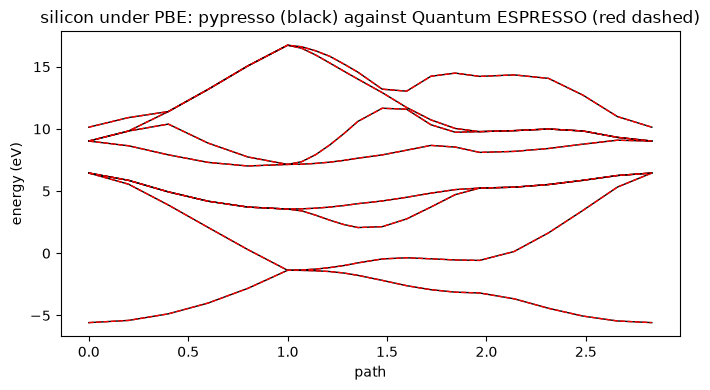

In [12]:
system, pseudos = load('si2-nc-pbe')
band_system = build_system(read_pw_input(CASES / 'si2-nc-pbe-bands.in'))
bands = run_bands(band_system, pseudos, scf.density)
ref_bands = reference('si2-nc-pbe-bands')

difference = np.abs(bands.eigenvalues_ev - ref_bands.eigenvalues[0])
print(f'largest eigenvalue difference from QE: {difference.max()*1e3:.3f} meV')
print(f'PBE gap: {bands.gap(8):.3f} eV   (experiment: 1.17 eV)')

fig, ax = plt.subplots(figsize=(7, 4))
for band in range(bands.eigenvalues_ev.shape[1]):
    ax.plot(bands.path_length, bands.eigenvalues_ev[:, band], 'k-', lw=1)
    ax.plot(bands.path_length, ref_bands.eigenvalues[0][:, band], 'r--', lw=1)
ax.set_ylabel('energy (eV)'); ax.set_xlabel('path')
ax.set_title('silicon under PBE: pypresso (black) against Quantum ESPRESSO (red dashed)')
fig.tight_layout()

The gap is around 0.6 eV against an experimental 1.17. **PBE does not fix the band gap** —
it is a better functional for energies, geometries and formation enthalpies, and its
Kohn-Sham gap is essentially LDA's. That is a property of the theory, not of this
implementation, and it is worth stating plainly next to a plot that otherwise looks like a
success: the agreement being demonstrated here is with Quantum ESPRESSO, to 0.05 meV, not
with the experiment.

## What this cost

Four extra FFTs per SCF iteration on the dense grid, plus a pointwise evaluation of a
longer expression, and on PAW a second pass over each atom's angular quadrature — which is
now 45 directions instead of 28. `PERFORMANCE.md` carries the measurement against QE for
the same cell with and without the correction.